In [1]:
import xarray as xr
import numpy as np
import os
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import BoundaryNorm

import scipy
from scipy.stats import ttest_ind

In [2]:
os.chdir('...')

data_coord = xr.open_dataset('ANHA4-EJM010_y2017m12d31_gridT.nc')

lat = data_coord.variables['nav_lat_grid_T']
lon = data_coord.variables['nav_lon_grid_T']
depth = data_coord.variables['deptht']

In [4]:
data_path_vs = '.../temp_vs'
data_path_vd = '.../temp_vd'

all_avg_vs = []
all_avg_vd = []

years = np.arange(2007, 2018)
vmin = -1
vmax = 1
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
years = np.arange(2007, 2018)

for idx, year in enumerate(years):
    print(f"▶️ Processing {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_Temperature.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_Temperature.npz'
    data_vs = np.load(os.path.join(data_path_vs, vs_file))['votemper']
    data_vd = np.load(os.path.join(data_path_vd, vd_file))['votemper']
    
    # From the surface to 55m deep
    avg_vs = np.nanmean(data_vs[:, 0:19], axis=1) 
    avg_vd = np.nanmean(data_vd[:, 0:19], axis=1)

    all_avg_vs.append(avg_vs)
    all_avg_vd.append(avg_vd)

▶️ Processing 2007...


/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_9235/244950639.py:25: RuntimeWarning: Mean of empty slice
  avg_vs = np.nanmean(data_vs[:, 0:19], axis=1)
/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_9235/244950639.py:26: RuntimeWarning: Mean of empty slice
  avg_vd = np.nanmean(data_vd[:, 0:19], axis=1)


▶️ Processing 2008...
▶️ Processing 2009...
▶️ Processing 2010...
▶️ Processing 2011...
▶️ Processing 2012...
▶️ Processing 2013...
▶️ Processing 2014...
▶️ Processing 2015...
▶️ Processing 2016...
▶️ Processing 2017...


In [5]:
all_avg_vs = np.stack(all_avg_vs, axis=0)
all_avg_vd = np.stack(all_avg_vd, axis=0)

In [6]:
all_avg_vs = all_avg_vs.reshape(-1, 800, 544)
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

In [7]:
dif_upper = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
dif_upper = np.clip(dif_upper, vmin, vmax)

/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_9235/540801256.py:1: RuntimeWarning: Mean of empty slice
  dif_upper = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)


In [8]:
stat_upper, p_val_upper = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [9]:
data_path_vs = '.../temp_vs'
data_path_vd = '.../temp_vd'

all_avg_vs = []
all_avg_vd = []

years = np.arange(2007, 2018)
vmin = -1
vmax = 1
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
years = np.arange(2007, 2018)

for idx, year in enumerate(years):
    print(f"▶️ Processando {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_Temperature.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_Temperature.npz'
    data_vs = np.load(os.path.join(data_path_vs, vs_file))['votemper']
    data_vd = np.load(os.path.join(data_path_vd, vd_file))['votemper']
    
    avg_vs = np.nanmean(data_vs[:, 19:32], axis=1)  
    avg_vd = np.nanmean(data_vd[:, 19:32], axis=1)

    all_avg_vs.append(avg_vs)
    all_avg_vd.append(avg_vd)

▶️ Processando 2007...


/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_9235/3599052532.py:24: RuntimeWarning: Mean of empty slice
  avg_vs = np.nanmean(data_vs[:, 19:32], axis=1)
/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_9235/3599052532.py:25: RuntimeWarning: Mean of empty slice
  avg_vd = np.nanmean(data_vd[:, 19:32], axis=1)


▶️ Processando 2008...
▶️ Processando 2009...
▶️ Processando 2010...
▶️ Processando 2011...
▶️ Processando 2012...
▶️ Processando 2013...
▶️ Processando 2014...
▶️ Processando 2015...
▶️ Processando 2016...
▶️ Processando 2017...


In [10]:
all_avg_vs = np.stack(all_avg_vs, axis=0)
all_avg_vd = np.stack(all_avg_vd, axis=0)

In [11]:
all_avg_vs = all_avg_vs.reshape(-1, 800, 544)
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

In [12]:
dif_lower = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
dif_lower = np.clip(dif_lower, vmin, vmax)

/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_9235/3725718542.py:1: RuntimeWarning: Mean of empty slice
  dif_lower = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)


In [13]:
stat_lower, p_val_lower = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

NameError: name 'figure_title' is not defined

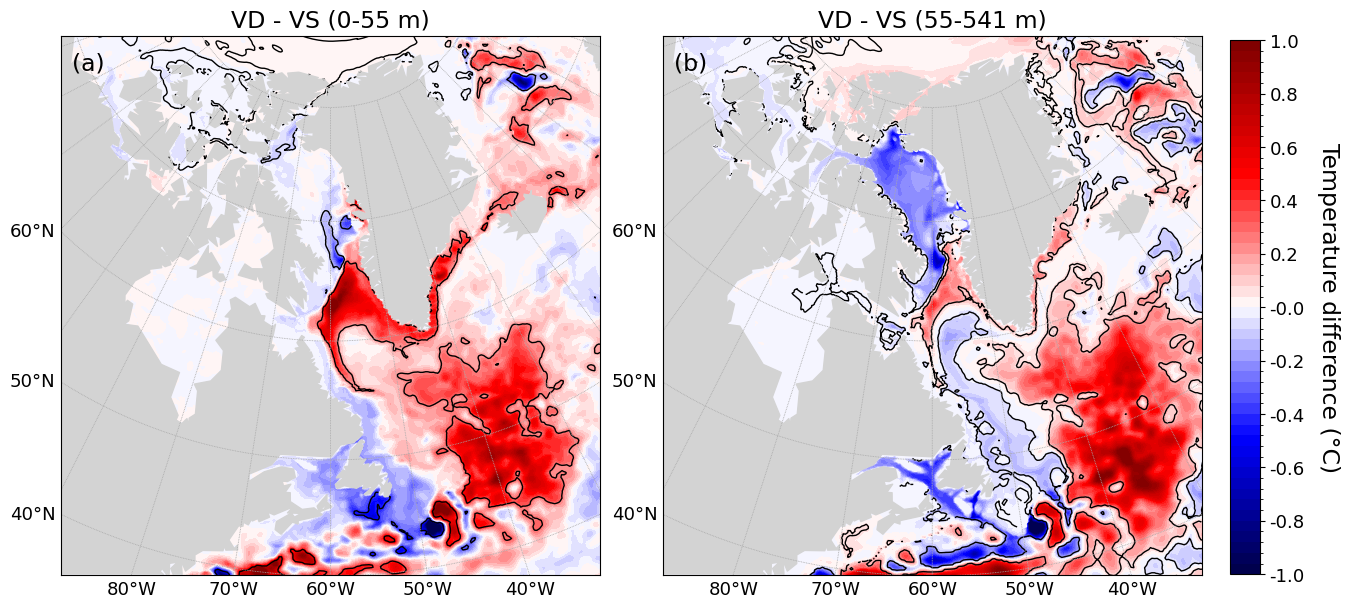

In [14]:
vmin = -1
vmax = 1
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

titles = ['VD - VS (0-55 m)', 'VD - VS (55-541 m)']
datasets = [dif_upper, dif_lower]
pvals = [p_val_upper, p_val_lower]

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, data, data2, title in zip(axs, datasets, pvals, titles):
    ax.set_title(title, fontsize=17)
    
    m = Basemap(projection='aea', resolution='c', width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)

    m.contourf(lon, lat, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)
    cs = m.contour(lon, lat, data2, latlon=True, levels=[0.01], colors='black', linewidths=1.0)

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=13)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0], linewidth=0.6, color='darkgray', fontsize=13)

cax = fig.add_axes([1.02, 0.05, 0.025, 0.89])
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Temperature difference (\u00B0C)', rotation=270, labelpad=25, fontsize = 17)

ticks = np.arange(vmin, vmax + 0.01, 0.2)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.1f}" for t in ticks])
cb.ax.tick_params(labelsize=13)  

labels = ['a', 'b']

for i, ax in enumerate(axs):
    ax.text(0.02, 0.97, f'({labels[i]})', transform=ax.transAxes,
            fontsize=17, va='top', ha='left')
    
figure_title = 'Figure6_TemperatureDifferences(0-55)(55-541)'
os.chdir('.../Figures5&6_Salinity_and_Temperature_Maps/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()
